MACHINR LEARNIG LAB
NAME:MEHTAB AHMED   
CMSID:023-24-0285 
SECTION H LAB 03
GITHUB LINK:https://github.com/mehtabahmeddev/MACHINE-LEARNING/tree/51485feaabe99db1f27419e0afc86ec88e3cb45c/LAB-03
dataset:clean_churn(telco churn)


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df=pd.read_csv("clean_churn.csv")
print(df.head(2))

#task 1
print(df.shape)
print(df.info())
print(df["Churn"].value_counts())


   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   

  TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling  \
0          No          No              No  Month-to-month              Yes   
1          No          No              No        One year               No   

      PaymentMethod MonthlyCharges  TotalCharges  Churn  
0  Electronic check          29.85         29.85     No  
1      Mailed check          56.95       1889.50     No  

[2 rows x 21 columns]
(7032, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 21 c

task 2
In this data set model has to predict the customer churn based on givven data ,
a customer with certain values of data is leaving the company 


In [4]:
#task 3
y = df["Churn"].map({"Yes": 1, "No": 0})
X = df.drop(columns=["customerID", "Churn"])


In [6]:
#task 4
X = pd.get_dummies(X, drop_first=True)


task 4: I used One-Hot Encoding to convert the categorical features into numeric values because most categorical variables in the Telco Customer Churn dataset (such as InternetService, Contract, and PaymentMethod) do not have a natural order. One-Hot Encoding creates a separate binary (True/False) column for each category, allowing the Decision Tree model to process the data correctly without introducing any false numerical relationships. The parameter drop_first=True was used to remove one category from each feature and avoid redundant columns.

In [7]:
#task 5
bool_cols = X.select_dtypes(include="bool").columns
X[bool_cols] = X[bool_cols].astype(int)
print(X.dtypes)
print("Missing values:", X.isnull().sum().sum())

SeniorCitizen                              int64
tenure                                     int64
MonthlyCharges                           float64
TotalCharges                             float64
gender_Male                                int64
Partner_Yes                                int64
Dependents_Yes                             int64
PhoneService_Yes                           int64
MultipleLines_No phone service             int64
MultipleLines_Yes                          int64
InternetService_Fiber optic                int64
InternetService_No                         int64
OnlineSecurity_No internet service         int64
OnlineSecurity_Yes                         int64
OnlineBackup_No internet service           int64
OnlineBackup_Yes                           int64
DeviceProtection_No internet service       int64
DeviceProtection_Yes                       int64
TechSupport_No internet service            int64
TechSupport_Yes                            int64
StreamingTV_No inter

In [8]:
#task 6
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

The dataset was split into 80% training data and 20% testing data using the train_test_split() function. The training set is used to train the Decision Tree model, while the testing set is used to evaluate its performance on unseen data. The parameter stratify=y was used to maintain the same proportion of churned and non-churned customers in both the training and testing sets. This ensures that both datasets represent the original class distribution and provides a fair evaluation of the model. The random_state=42 parameter was used to make the split reproducible.

In [22]:
#task 7
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape:", y_test.shape)

X_train shape: (5625, 30)
X_test shape: (1407, 30)
y_train shape: (5625,)
y_test shape: (1407,)


After splitting the dataset, the shapes of the training and testing sets were checked to verify that the split was successful. The output showed that 5,625 samples were assigned to the training set and 1,407 samples to the testing set. Each sample contains 30 feature columns. This confirms that the dataset was correctly divided using an 80/20 split and is ready for training and testing the Decision Tree model.

You can also mention your results:

X_train: (5625, 30)
X_test: (1407, 30)
y_train: (5625,)
y_test: (1407,)

In [9]:
#task8
from sklearn.tree import DecisionTreeClassifier as dtc

dt_model = dtc(random_state=42)

dt_model.fit(X_train, y_train)

y_train_pred = dt_model.predict(X_train)
y_test_pred = dt_model.predict(X_test)

Tree Depth: 23


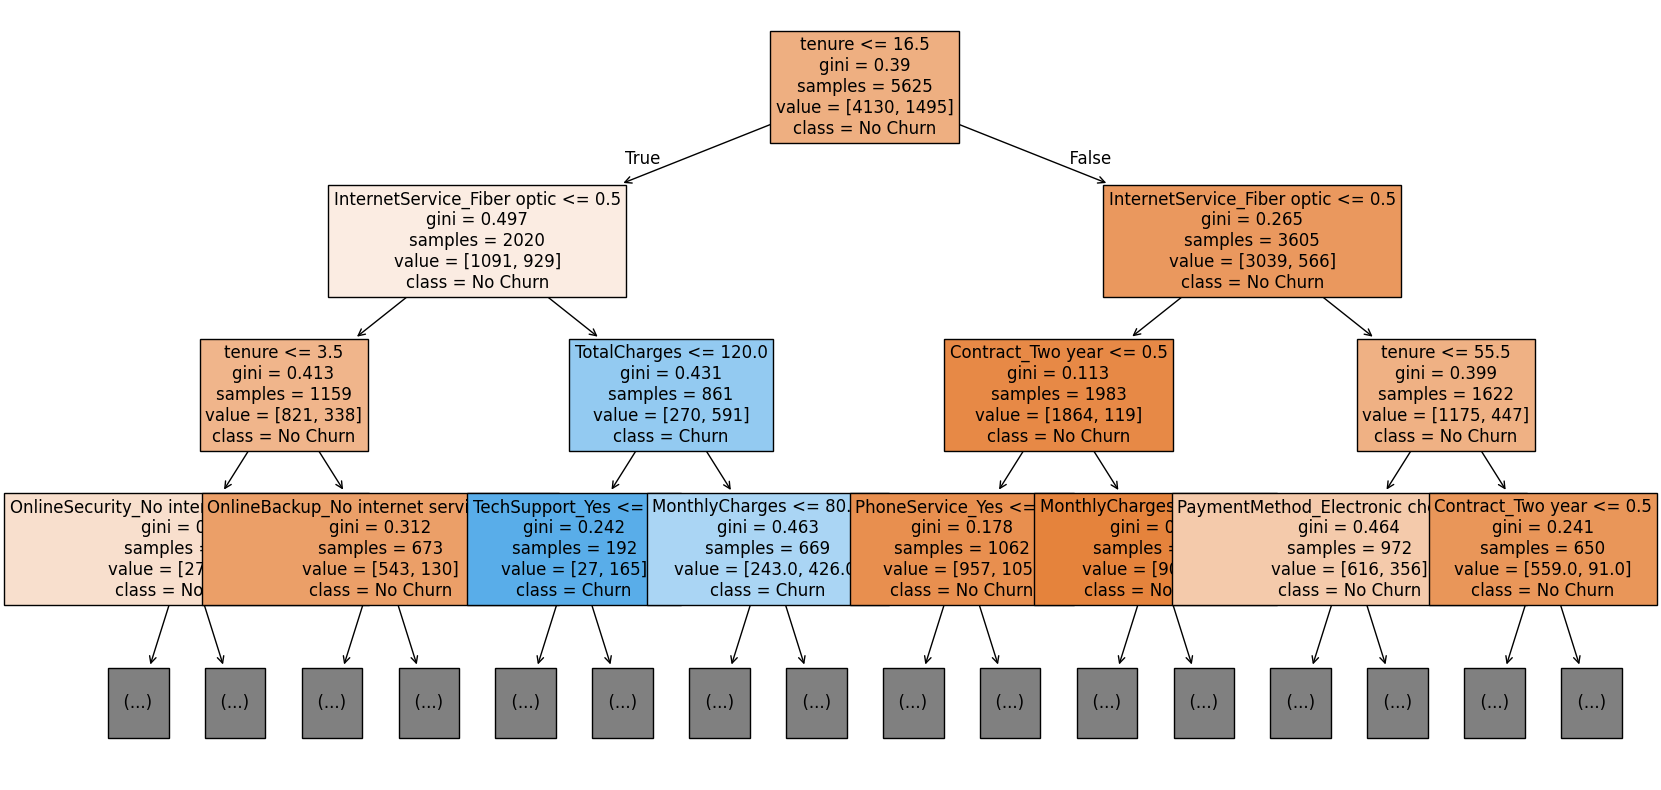

In [37]:
# task9
print("Tree Depth:", dt_model.get_depth())


#figured out myself how to print the tree in jupyter may be out of course
plt.figure(figsize=(20, 10))
plot_tree(
    dt_model,
    feature_names=X.columns,
    class_names=["No Churn", "Churn"],
    max_depth=3,
    filled=True,
    fontsize=12
)

plt.show()

The Decision Tree grew to a depth of 23. I was surprised that the tree became this deep because I did not set any depth limit. This shows that the model learned many detailed patterns from the training data, which could lead to overfitting.

In [39]:
#task10

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-score :", f1)
metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Score": [accuracy, precision, recall, f1]
})

print(metrics)

Accuracy : 0.7185501066098081
Precision: 0.4701086956521739
Recall   : 0.4625668449197861
F1-score : 0.46630727762803237
      Metric     Score
0   Accuracy  0.718550
1  Precision  0.470109
2     Recall  0.462567
3   F1-score  0.466307


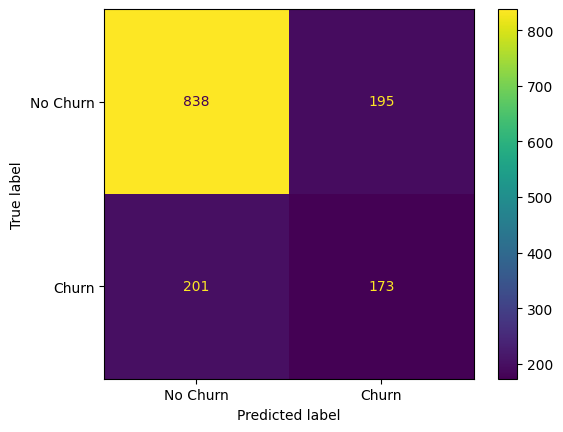

Actual churners correctly caught: 173
Actual churners missed: 201


In [41]:
#task 11
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Churn", "Churn"]
)

disp.plot()
plt.show()

tn, fp, fn, tp = cm.ravel()

print("Actual churners correctly caught:", tp)
print("Actual churners missed:", fn)

task12
Because the dataset is imbalanced, I would trust recall and F1-score more than accuracy alone. Recall is especially important because it tells us how many of the actual churners the model successfully identifies. In our results, the model missed 201 out of 374 churners, so recall is important for checking how well we catch customers who are likely to leave. F1-score is also useful because it considers both precision and recall.

In [10]:
#task13
from sklearn.metrics import accuracy_score
train_accuracy = accuracy_score(y_train, y_train_pred)
test_accuracy = accuracy_score(y_test, y_test_pred)
print("Training Accuracy:", train_accuracy)
print("Test Accuracy:", test_accuracy)
print("Accuracy Gap:", train_accuracy - test_accuracy)

Training Accuracy: 0.9987555555555555
Test Accuracy: 0.7185501066098081
Accuracy Gap: 0.2802054489457474


The baseline Decision Tree has a training accuracy of 99.88% and a test accuracy of 71.86%. The accuracy gap is about 28%, which is quite large. This means the model performs extremely well on the training data but much worse on unseen test data. This large gap strongly suggests that the Decision Tree is overfitting.


In [11]:
# Task 14

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
import pandas as pd

depths = [2, 3, 4, 5, 6, 8, 10, None]

results = []

for depth in depths:
    model = DecisionTreeClassifier(
        max_depth=depth,
        random_state=42
    )
    
    model.fit(X_train, y_train)
    
    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)
    
    train_acc = accuracy_score(y_train, train_pred)
    test_acc = accuracy_score(y_test, test_pred)
    
    results.append([depth, train_acc, test_acc])

results_df = pd.DataFrame(
    results,
    columns=["max_depth", "Train Accuracy", "Test Accuracy"]
)

print(results_df)

   max_depth  Train Accuracy  Test Accuracy
0        2.0        0.791289       0.784648
1        3.0        0.791289       0.784648
2        4.0        0.796089       0.783227
3        5.0        0.801956       0.778252
4        6.0        0.812978       0.785359
5        8.0        0.836622       0.782516
6       10.0        0.874311       0.752665
7        NaN        0.998756       0.718550


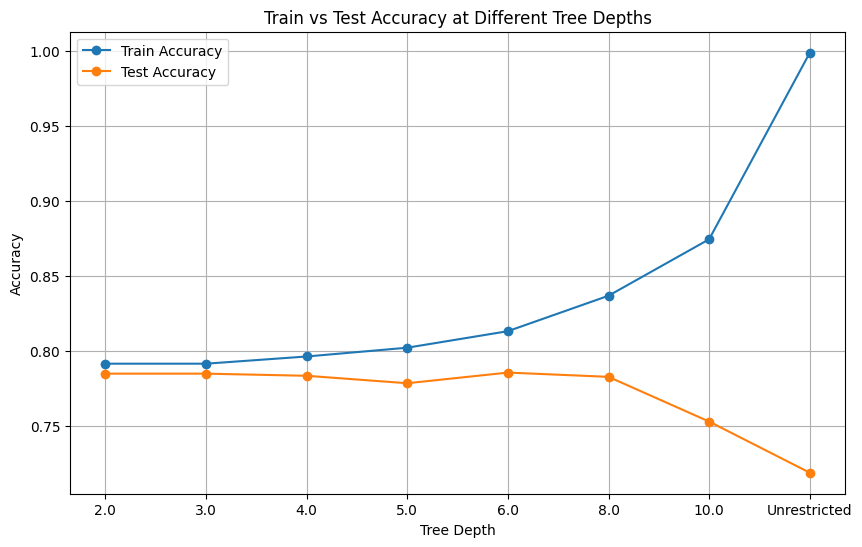

In [12]:
# Task 15

import matplotlib.pyplot as plt

depth_labels = results_df["max_depth"].fillna("Unrestricted").astype(str)

plt.figure(figsize=(10, 6))

plt.plot(
    depth_labels,
    results_df["Train Accuracy"],
    marker="o",
    label="Train Accuracy"
)

plt.plot(
    depth_labels,
    results_df["Test Accuracy"],
    marker="o",
    label="Test Accuracy"
)

plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Train vs Test Accuracy at Different Tree Depths")

plt.legend()
plt.grid(True)

plt.show()

The graph compares training and test accuracy for different tree depths. The training accuracy keeps increasing as the tree depth increases, while the test accuracy remains around 0.78 and then decreases. Overfitting becomes more noticeable around depth 8 to 10, where training accuracy continues to increase but test accuracy starts to fall. At depth 10, the training accuracy is 0.874 while test accuracy drops to 0.753. This shows that deeper trees learn the training data too closely and do not generalize as well to new data.


task16
I chose `max_depth=6` as the best model. It has the highest test accuracy of about 78.54% while its training accuracy is about 81.30%, so the gap is small. This gives a better balance between learning the training data and performing well on unseen data.


In [52]:
#task 17
# Task 17

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

best_model = DecisionTreeClassifier(
    max_depth=6,
    random_state=42
)

best_model.fit(X_train, y_train)

y_best_pred = best_model.predict(X_test)

accuracy = accuracy_score(y_test, y_best_pred)
precision = precision_score(y_test, y_best_pred)
recall = recall_score(y_test, y_best_pred)
f1 = f1_score(y_test, y_best_pred)

metrics_depth6 = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score"],
    "Score": [accuracy, precision, recall, f1]
})

print(metrics_depth6)

      Metric     Score
0   Accuracy  0.785359
1  Precision  0.611111
2     Recall  0.529412
3   F1-score  0.567335


In [56]:
# Task 18

entropy_model = DecisionTreeClassifier(
    max_depth=6,
    criterion="entropy",
    random_state=42
)

entropy_model.fit(X_train, y_train)

y_entropy_pred = entropy_model.predict(X_test)

accuracy = accuracy_score(y_test, y_entropy_pred)
precision = precision_score(y_test, y_entropy_pred)
recall = recall_score(y_test, y_entropy_pred)
f1 = f1_score(y_test, y_entropy_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)

Accuracy: 0.7882018479033405
Precision: 0.5969387755102041
Recall: 0.6256684491978609
F1-score: 0.6109660574412533


In [58]:
# Task 19

importances = best_model.feature_importances_
feature_importance = pd.Series(
    importances,
    index=X.columns
).sort_values(ascending=False)

print("Top 5 Important Features:")
print(feature_importance.head(5))

Top 5 Important Features:
tenure                                0.405471
InternetService_Fiber optic           0.309883
MonthlyCharges                        0.057752
TotalCharges                          0.054916
OnlineSecurity_No internet service    0.038577
dtype: float64


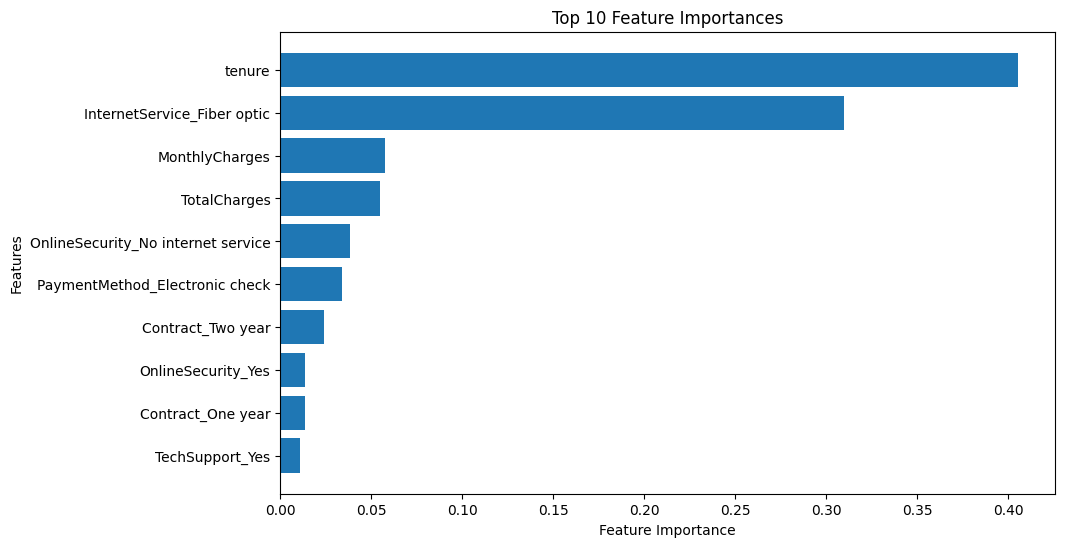

In [59]:
plt.figure(figsize=(10, 6))

top_features = feature_importance.head(10).sort_values()

plt.barh(top_features.index, top_features.values)

plt.xlabel("Feature Importance")
plt.ylabel("Features")
plt.title("Top 10 Feature Importances")

plt.show()

The feature importance results show that tenure is the most important feature for predicting customer churn. Other important features include InternetService_Fiber optic, MonthlyCharges, TotalCharges, and OnlineSecurity_No internet service. These features had the highest importance values in the selected Decision Tree.

task 20The important features from the Decision Tree generally agree with the patterns found in Lab 2 EDA. For example, tenure and MonthlyCharges were related to customer churn, where customers with shorter tenure and higher charges were more likely to churn. This shows that the model learned patterns that were also observed during the EDA.

task 21
I selected the Decision Tree with max_depth=6 because it gave the best balance between training and test performance. It achieved about 78.54% test accuracy, while the training accuracy was about 81.30%, so the gap was much smaller than the unrestricted tree. The baseline tree was clearly overfitting because it had almost 100% training accuracy but only about 71.86% test accuracy. The main limitations are that the dataset is imbalanced and the Decision Tree may still not identify all customers who will churn. The feature importance results showed that tenure, Internet Service, Monthly Charges, and Total Charges were important for predicting churn.

task 22
If I had more time, I would try other machine learning algorithms such as Random Forest or Logistic Regression and compare their results with the Decision Tree. I would also try better feature engineering and handle the class imbalance so that the model can identify more churn customers. I would compare the models using recall and F1-score, not only accuracy, because missing a customer who is likely to churn is important.

In [63]:
import pandas as pd
import math

data = {
    "Outlook": [
        "Sunny", "Sunny", "Overcast", "Rain",
        "Rain", "Rain", "Overcast", "Sunny",
        "Sunny", "Rain", "Sunny", "Overcast",
        "Overcast", "Rain"
    ],

    "Temperature": [
        "Hot", "Hot", "Hot", "Mild",
        "Cool", "Cool", "Cool", "Mild",
        "Cool", "Mild", "Mild", "Mild",
        "Hot", "Mild"
    ],

    "Humidity": [
        "High", "High", "High", "High",
        "Normal", "Normal", "Normal", "High",
        "Normal", "Normal", "Normal", "High",
        "Normal", "High"
    ],

    "Wind": [
        "Weak", "Strong", "Weak", "Weak",
        "Weak", "Strong", "Strong", "Weak",
        "Weak", "Weak", "Strong", "Strong",
        "Weak", "Strong"
    ],

    "Play": [
        "No", "No", "Yes", "Yes",
        "Yes", "No", "Yes", "No",
        "Yes", "Yes", "Yes", "Yes",
        "Yes", "No"
    ]
}

df_play = pd.DataFrame(data)

print(df_play)


# ENTROPY FUNCTION
def entropy(data):
    values = data.value_counts()
    total = len(data)

    ent = 0

    for count in values:
        p = count / total
        ent -= p * math.log2(p)

    return ent


# INFORMATION GAIN FUNCTION
def information_gain(df, attribute, target):

    total_entropy = entropy(df[target])

    weighted_entropy = 0

    for value in df[attribute].unique():

        subset = df[df[attribute] == value]

        weight = len(subset) / len(df)

        weighted_entropy += weight * entropy(subset[target])

    gain = total_entropy - weighted_entropy

    return gain


attributes = ["Outlook", "Temperature", "Humidity", "Wind"]

print("Information Gain Values:")

for attribute in attributes:
    gain = information_gain(df_play, attribute, "Play")
    print(attribute, "=", round(gain, 4))

     Outlook Temperature Humidity    Wind Play
0      Sunny         Hot     High    Weak   No
1      Sunny         Hot     High  Strong   No
2   Overcast         Hot     High    Weak  Yes
3       Rain        Mild     High    Weak  Yes
4       Rain        Cool   Normal    Weak  Yes
5       Rain        Cool   Normal  Strong   No
6   Overcast        Cool   Normal  Strong  Yes
7      Sunny        Mild     High    Weak   No
8      Sunny        Cool   Normal    Weak  Yes
9       Rain        Mild   Normal    Weak  Yes
10     Sunny        Mild   Normal  Strong  Yes
11  Overcast        Mild     High  Strong  Yes
12  Overcast         Hot   Normal    Weak  Yes
13      Rain        Mild     High  Strong   No
Information Gain Values:
Outlook = 0.2467
Temperature = 0.0292
Humidity = 0.1518
Wind = 0.0481


In [64]:
def id3(df, attributes, target, level=0):

    # If all examples have the same target
    if len(df[target].unique()) == 1:
        return df[target].iloc[0]

    # If no attributes are left
    if len(attributes) == 0:
        return df[target].mode()[0]

    print("\n" + "  " * level + "Node")

    # Calculate gain for every attribute
    gains = {}

    for attribute in attributes:
        gains[attribute] = information_gain(df, attribute, target)
        print(
            "  " * level +
            attribute + " Gain = " +
            str(round(gains[attribute], 4))
        )

    # Select attribute with highest gain
    best_attribute = max(gains, key=gains.get)

    print(
        "  " * level +
        "Best Attribute = " +
        best_attribute
    )

    tree = {best_attribute: {}}

    remaining_attributes = [
        attr for attr in attributes
        if attr != best_attribute
    ]

    # Create brancheS
    for value in df[best_attribute].unique():

        subset = df[df[best_attribute] == value]

        tree[best_attribute][value] = id3(
            subset,
            remaining_attributes,
            target,
            level + 1
        )

    return tree

In [66]:
attributes = ["Outlook", "Temperature", "Humidity", "Wind"]

tree = id3(
    df_play,
    attributes,
    "Play"
)

print("\nFinal ID3 Tree:")
print(tree)


Node
Outlook Gain = 0.2467
Temperature Gain = 0.0292
Humidity Gain = 0.1518
Wind Gain = 0.0481
Best Attribute = Outlook

  Node
  Temperature Gain = 0.571
  Humidity Gain = 0.971
  Wind Gain = 0.02
  Best Attribute = Humidity

  Node
  Temperature Gain = 0.02
  Humidity Gain = 0.02
  Wind Gain = 0.971
  Best Attribute = Wind

Final ID3 Tree:
{'Outlook': {'Sunny': {'Humidity': {'High': 'No', 'Normal': 'Yes'}}, 'Overcast': 'Yes', 'Rain': {'Wind': {'Weak': 'Yes', 'Strong': 'No'}}}}


The ID3 algorithm calculates the entropy of the target and then calculates the information gain for each attribute. The attribute with the highest gain is selected as the decision node. This process is repeated for each branch until the data can be classified. In this dataset, Outlook has the highest gain at the first step, so it becomes the root of the tree.